<a href="https://colab.research.google.com/github/cesa3/nn-ga/blob/main/NN_%2BGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

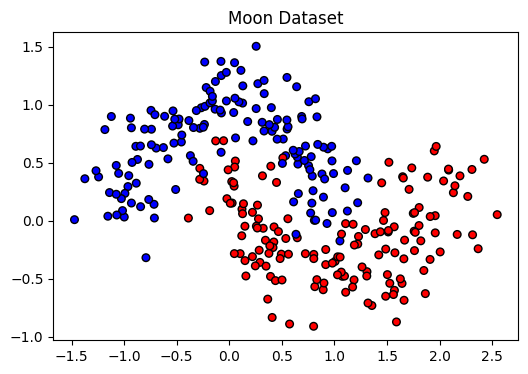

In [ ]:
# Generate nonlinear moon dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Plot
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', s=30)
plt.title("Moon Dataset")
plt.show()

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def nn_forward(X, weights):
    """
    Architecture: 2 -> 4 -> 1
    weights: flat array ที่ GA จะปรับ
    """
    # Unpack weights
    # Layer 1: (2x4) + bias(4) = 12 params
    # Layer 2: (4x1) + bias(1) = 5 params
    # Total = 17 params
    W1 = weights[0:8].reshape(2, 4)
    b1 = weights[8:12]
    W2 = weights[12:16].reshape(4, 1)
    b2 = weights[16:17]

    # Forward pass
    h = sigmoid(X @ W1 + b1)       # hidden layer
    out = sigmoid(h @ W2 + b2)     # output layer
    return out.flatten()

def compute_accuracy(X, y, weights):
    pred = nn_forward(X, weights) >= 0.5
    return np.mean(pred == y)

def compute_loss(weights, X, y):
    pred = nn_forward(X, weights)
    pred = np.clip(pred, 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))

N_WEIGHTS = 17

In [ ]:
from sklearn.neural_network import MLPClassifier

# Train with backprop
mlp = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='logistic',
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train, y_train)

bp_train_acc = mlp.score(X_train, y_train)
bp_test_acc  = mlp.score(X_test, y_test)

print(f"[Backprop] Train Acc: {bp_train_acc:.4f} | Test Acc: {bp_test_acc:.4f}")

[Backprop] Train Acc: 0.8583 | Test Acc: 0.9000


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
def genetic_algorithm(X, y, n_weights=17,
                       pop_size=100, generations=300,
                       mutation_rate=0.1, mutation_scale=0.5):

    # Init population
    population = np.random.randn(pop_size, n_weights)
    best_weights = None
    best_loss = np.inf
    history = []

    for gen in range(generations):
        # Fitness = negative loss (lower loss = higher fitness)
        losses = np.array([compute_loss(ind, X, y) for ind in population])
        fitness = -losses

        # Track best
        idx_best = np.argmin(losses)
        if losses[idx_best] < best_loss:
            best_loss = losses[idx_best]
            best_weights = population[idx_best].copy()
        history.append(best_loss)

        # Selection: tournament
        def tournament_select():
            candidates = np.random.choice(pop_size, 5, replace=False)
            return population[candidates[np.argmax(fitness[candidates])]]

        # Create next generation
        new_pop = [best_weights.copy()]  # elitism: keep best
        while len(new_pop) < pop_size:
            parent1 = tournament_select()
            parent2 = tournament_select()

            # Crossover (single point)
            pt = np.random.randint(1, n_weights)
            child = np.concatenate([parent1[:pt], parent2[pt:]])

            # Mutation
            mask = np.random.rand(n_weights) < mutation_rate
            child[mask] += np.random.randn(mask.sum()) * mutation_scale

            new_pop.append(child)

        population = np.array(new_pop)

        if (gen+1) % 50 == 0:
            acc = compute_accuracy(X, y, best_weights)
            print(f"Gen {gen+1:3d} | Loss: {best_loss:.4f} | Acc: {acc:.4f}")

    return best_weights, history

# Run GA
print("Training with Genetic Algorithm...")
ga_weights, ga_history = genetic_algorithm(X_train, y_train)

Training with Genetic Algorithm...
Gen  50 | Loss: 0.2651 | Acc: 0.8875
Gen 100 | Loss: 0.1338 | Acc: 0.9625
Gen 150 | Loss: 0.0977 | Acc: 0.9625
Gen 200 | Loss: 0.0861 | Acc: 0.9625
Gen 250 | Loss: 0.0800 | Acc: 0.9625
Gen 300 | Loss: 0.0778 | Acc: 0.9625


In [ ]:
ga_train_acc = compute_accuracy(X_train, y_train, ga_weights)
ga_test_acc  = compute_accuracy(X_test,  y_test,  ga_weights)

print("="*40)
print(f"[Backprop] Train: {bp_train_acc:.4f} | Test: {bp_test_acc:.4f}")
print(f"[GA]       Train: {ga_train_acc:.4f} | Test: {ga_test_acc:.4f}")
print("="*40)

[Backprop] Train: 0.8583 | Test: 0.9000
[GA]       Train: 0.9625 | Test: 0.9667


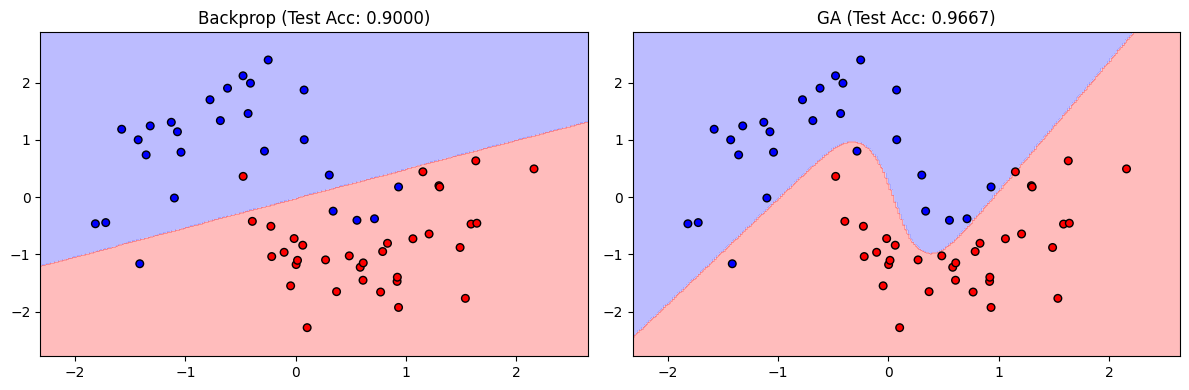

In [ ]:
def plot_boundary(X, y, predict_fn, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = predict_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', s=30)
    plt.title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])
plot_boundary(X_test, y_test,
              lambda X: (mlp.predict_proba(X)[:,1] >= 0.5).astype(int),
              f"Backprop (Test Acc: {bp_test_acc:.4f})")

plt.sca(axes[1])
plot_boundary(X_test, y_test,
              lambda X: (nn_forward(X, ga_weights) >= 0.5).astype(int),
              f"GA (Test Acc: {ga_test_acc:.4f})")

plt.tight_layout()
plt.show()

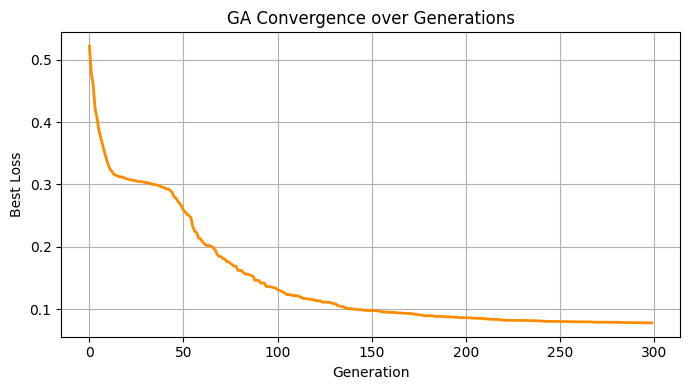

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(ga_history, color='darkorange', linewidth=2)
plt.xlabel("Generation")
plt.ylabel("Best Loss")
plt.title("GA Convergence over Generations")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def lame_v1(X, y, pop_size=80, generations=200,
            age_threshold=20,   # weight อายุเกินนี้ → repair
            alpha=0.6,          # strength ของ population signal
            beta=0.2,           # noise
            seed=42):
    """
    LAME v1: Lifespan-Aware Mutation Evolution

    Key idea:
    - แต่ละ weight มี age counter
    - ถ้า weight ไม่ได้ช่วยให้ loss ลด → age++
    - ถ้า age > threshold → ไม่ reset random
      แต่ดูว่า individual ที่ดีกว่าใน population
      weight ตัวนั้นอยู่ที่ไหน แล้วขยับไปทางนั้น
      feel เหมือน gradient แต่ใช้ population เป็น signal
    """
    np.random.seed(seed)

    # Init population
    pop  = np.random.randn(pop_size, N_WEIGHTS) * 0.1

    # Age matrix: shape (pop_size, N_WEIGHTS)
    # แต่ละ weight ของแต่ละ individual มี age ของตัวเอง
    ages = np.zeros((pop_size, N_WEIGHTS), dtype=int)

    # Previous loss ของแต่ละ individual (เพื่อเช็คว่า weight ช่วยไหม)
    prev_losses = np.full(pop_size, np.inf)

    best_w, best_loss = None, np.inf
    hist_train, hist_test, hist_loss = [], [], []
    repair_counts = []  # track ว่า repair กี่ weights ต่อ gen
    start = time.time()

    for gen in range(generations):
        # Evaluate
        losses = np.array([compute_loss(ind, X, y) for ind in pop])
        idx_b  = np.argmin(losses)

        if losses[idx_b] < best_loss:
            best_loss = losses[idx_b]
            best_w    = pop[idx_b].copy()

        hist_loss.append(best_loss)
        hist_train.append(compute_acc(best_w, X, y))
        hist_test.append(compute_acc(best_w, X_test, y_test))

        # Update age
        # weight ที่ individual ไม่ดีขึ้น → age ทุก weight ของ individual นั้น++
        for i in range(pop_size):
            if losses[i] >= prev_losses[i]:
                ages[i] += 1  # individual ไม่ดีขึ้น → age เพิ่ม
            else:
                # ดีขึ้น → reset age ของ individual นั้น
                ages[i] = np.maximum(0, ages[i] - 2)
        prev_losses = losses.copy()

        # Population-guided repair
        # หา "better" individuals = top 25%
        top_k    = max(5, pop_size // 4)
        top_idx  = np.argsort(losses)[:top_k]
        top_pop  = pop[top_idx]              # shape: (top_k, N_WEIGHTS)
        top_mean = top_pop.mean(axis=0)      # mean weight ของ top individuals

        n_repaired = 0
        alpha_t = alpha * (0.05/alpha) ** (gen/generations)
        beta_t  = beta  * (0.5/beta)  ** (gen/generations)

        for i in range(pop_size):
            # หา weight ที่ age เกิน threshold
            old_mask = ages[i] > age_threshold
            if old_mask.sum() == 0:
                continue

            n_repaired += old_mask.sum()

            # Population-guided repair
            # direction = top_mean - current (เหมือน gradient ที่ชี้ไปหา better region)
            direction = top_mean - pop[i]

            # ขยับไปทาง direction + noise (เฉพาะ weight ที่แก่)
            pop[i, old_mask] += (alpha_t * direction[old_mask]
                                 + beta_t * np.random.randn(old_mask.sum()))

            # Reset age ของ weight ที่ repair แล้ว
            ages[i, old_mask] = 0

        repair_counts.append(n_repaired)

        # Standard GA operations (selection + crossover)
        fitness = -losses
        def tournament():
            idx = np.random.choice(pop_size, 5, replace=False)
            return pop[idx[np.argmax(fitness[idx])]]

        new_pop  = [best_w.copy()]
        new_ages = [np.zeros(N_WEIGHTS, dtype=int)]

        while len(new_pop) < pop_size:
            p1_idx = np.random.choice(top_idx)
            p2_idx = np.random.choice(pop_size)
            p1, p2 = pop[p1_idx], pop[p2_idx]

            # Layer-wise crossover (ไม่ตัดกลาง filter)
            layer_boundaries = [0, 48, 320, 337]
            child      = p1.copy()
            child_ages = ages[p1_idx].copy()

            for li in range(len(layer_boundaries)-1):
                if np.random.rand() < 0.5:
                    s, e = layer_boundaries[li], layer_boundaries[li+1]
                    child[s:e]      = p2[s:e]
                    child_ages[s:e] = ages[p2_idx, s:e]

            # Small random mutation
            mut_scale = beta_t * 0.5
            mask = np.random.rand(N_WEIGHTS) < 0.05
            child[mask] += np.random.randn(mask.sum()) * mut_scale

            new_pop.append(child)
            new_ages.append(child_ages)

        pop  = np.array(new_pop)
        ages = np.array(new_ages)

        if (gen+1) % 50 == 0:
            print(f"  Gen {gen+1:3d} | Loss: {best_loss:.4f} | "
                  f"Train: {hist_train[-1]:.4f} | Test: {hist_test[-1]:.4f} | "
                  f"Repaired: {np.mean(repair_counts[-10:]):.0f} weights/gen")

    elapsed = time.time() - start
    return best_w, hist_train, hist_test, hist_loss, repair_counts, elapsed

print("Running LAME v1...")
lame_w, lame_tr, lame_te, lame_loss, lame_repairs, lame_time = lame_v1(
    X_train, y_train
)
print(f"\n[LAME v1] Train: {lame_tr[-1]:.4f} | Test: {lame_te[-1]:.4f} | Time: {lame_time:.1f}s")

Running LAME v1...


NameError: name 'compute_acc' is not defined

Train: (400, 2) | Test: (100, 2)
[Backprop] Test: 0.9400 | Time: 0.18s

Running single runs for loss curves...
  Standard GA...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  GI-GA...
  LAME v1...

Running 5 runs each for mean±std...

[Standard GA]
  [GA] Run 1 Test: 0.9700
  [GA] Run 2 Test: 0.9800
  [GA] Run 3 Test: 0.9700
  [GA] Run 4 Test: 0.9700
  [GA] Run 5 Test: 0.9700

[GI-GA]
  [GI-GA] Run 1 Test: 0.9700
  [GI-GA] Run 2 Test: 0.9600
  [GI-GA] Run 3 Test: 0.9700
  [GI-GA] Run 4 Test: 0.9600
  [GI-GA] Run 5 Test: 0.9400

[LAME v1]
  [LAME] Run 1 Test: 0.9800
  [LAME] Run 2 Test: 0.9700
  [LAME] Run 3 Test: 0.9600
  [LAME] Run 4 Test: 0.9800
  [LAME] Run 5 Test: 0.9800

Method                     Test Acc (mean±std)       Time
Backprop (Adam)               0.9400±0.0000      0.18s
Standard GA                   0.9720±0.0040       3.3s
Gradient-informed GA          0.9600±0.0110       4.5s
LAME v1                       0.9740±0.0080       3.1s


/tmp/ipykernel_322/3521870842.py:443: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_322/3521870842.py:443: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_322/3521870842.py:443: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_322/3521870842.py:443: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_322/3521870842.py:443: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_322/3521870842.py:443: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_322/3521870842.py:444: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  p

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/LAME_results.png'

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3635 (\N{THAI CHARACTER SAR

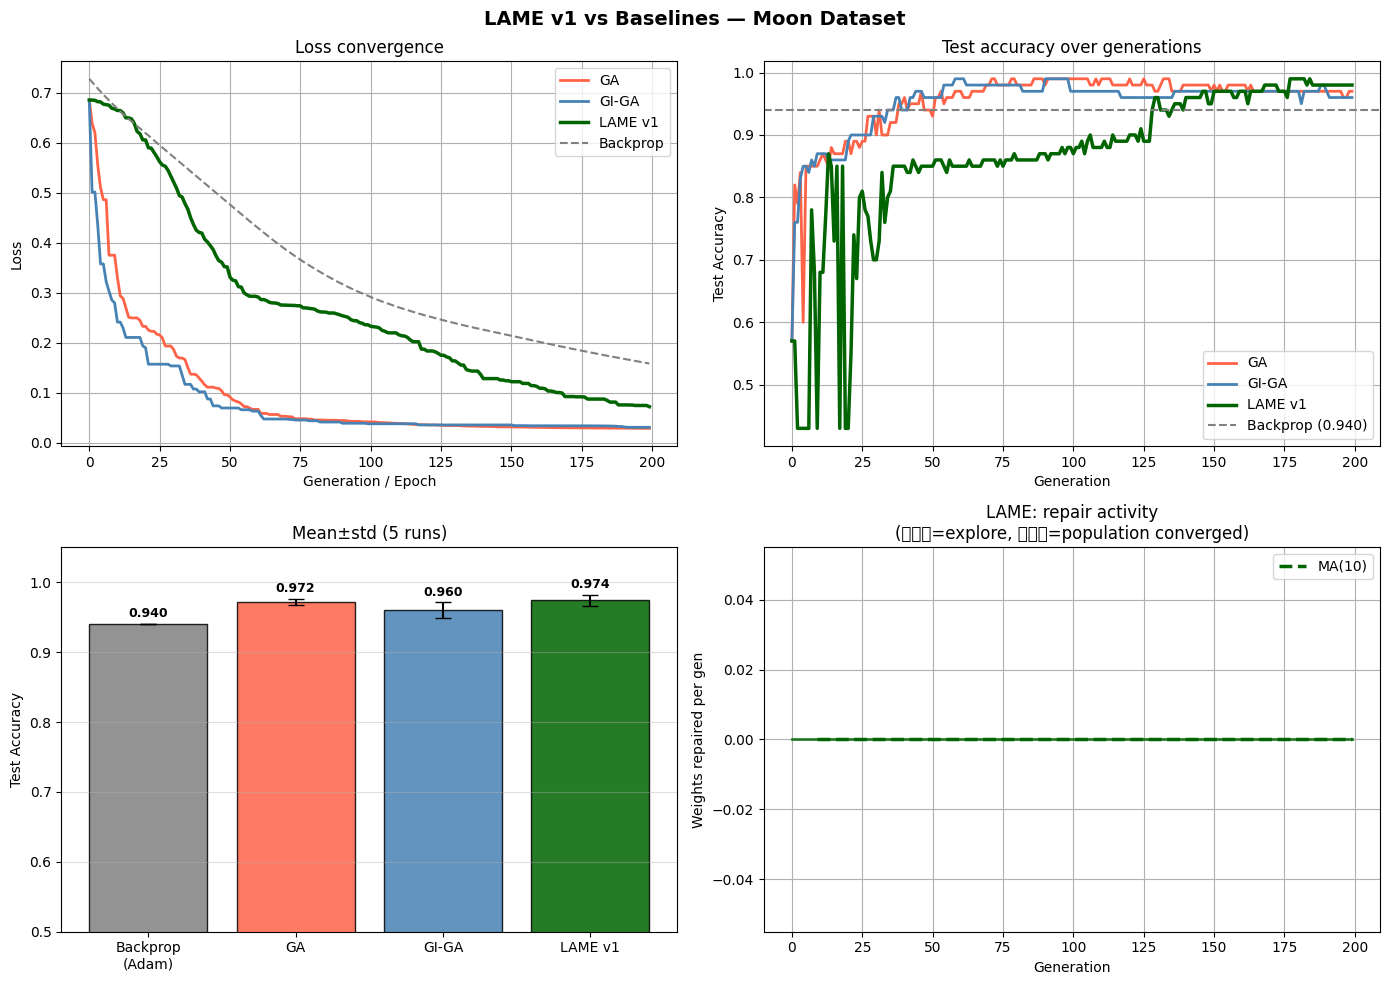

In [ ]:
# ============================================================
# LAME v1 — Lifespan-Aware Memory Evolution
# เปรียบเทียบ: Backprop vs Standard GA vs GI-GA vs LAME v1
# Dataset: Moon (nonlinear classification)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# ============================================================
# 0. Config
# ============================================================
SEED     = 42
N_RUNS   = 5
N_WEIGHTS = 337  # 2→16→16→1
np.random.seed(SEED)

# ============================================================
# 1. Dataset
# ============================================================
X, y = make_moons(n_samples=500, noise=0.2, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ============================================================
# 2. Neural Network (2→16→16→1, ReLU hidden, Sigmoid output)
# ============================================================
def relu(x):    return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def unpack(w):
    idx = 0
    W1 = w[idx:idx+32].reshape(2, 16);   idx += 32
    b1 = w[idx:idx+16];                   idx += 16
    W2 = w[idx:idx+256].reshape(16, 16);  idx += 256
    b2 = w[idx:idx+16];                   idx += 16
    W3 = w[idx:idx+16].reshape(16, 1);    idx += 16
    b3 = w[idx:idx+1]
    return W1, b1, W2, b2, W3, b3

def nn_forward(X, w):
    W1, b1, W2, b2, W3, b3 = unpack(w)
    h1  = relu(X @ W1 + b1)
    h2  = relu(h1 @ W2 + b2)
    return sigmoid(h2 @ W3 + b3).flatten()

def compute_loss(w, X, y):
    p = np.clip(nn_forward(X, w), 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def compute_acc(w, X, y):
    return np.mean((nn_forward(X, w) >= 0.5) == y)

# ============================================================
# 3. Backprop (Adam) — baseline
# ============================================================
def run_backprop(seed=SEED):
    t0  = time.time()
    mlp = MLPClassifier(
        hidden_layer_sizes=(16, 16),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=seed
    )
    mlp.fit(X_train, y_train)
    elapsed = time.time() - t0
    return mlp.score(X_test, y_test), elapsed, mlp.loss_curve_

bp_te, bp_time, bp_loss = run_backprop()
print(f"[Backprop] Test: {bp_te:.4f} | Time: {bp_time:.2f}s")

# ============================================================
# 4. Standard GA
# ============================================================
LAYER_BOUNDARIES = [0, 48, 320, 337]  # layer boundaries ใน weight vector

def standard_ga(X, y, pop_size=80, generations=200, seed=SEED):
    np.random.seed(seed)
    pop = np.random.randn(pop_size, N_WEIGHTS) * 0.1

    best_w, best_loss          = None, np.inf
    hist_train, hist_test, hist_loss = [], [], []
    start = time.time()

    for gen in range(generations):
        losses  = np.array([compute_loss(ind, X, y) for ind in pop])
        idx_b   = np.argmin(losses)

        if losses[idx_b] < best_loss:
            best_loss = losses[idx_b]
            best_w    = pop[idx_b].copy()

        hist_loss.append(best_loss)
        hist_train.append(compute_acc(best_w, X, y))
        hist_test.append(compute_acc(best_w, X_test, y_test))

        fitness = -losses
        alpha_t = 0.5 * (0.01 / 0.5) ** (gen / generations)

        def tournament():
            idx = np.random.choice(pop_size, 5, replace=False)
            return pop[idx[np.argmax(fitness[idx])]]

        new_pop = [best_w.copy()]
        while len(new_pop) < pop_size:
            p1, p2 = tournament(), tournament()
            pt      = np.random.randint(1, N_WEIGHTS)
            child   = np.concatenate([p1[:pt], p2[pt:]])
            mask    = np.random.rand(N_WEIGHTS) < 0.1
            child[mask] += np.random.randn(mask.sum()) * alpha_t
            new_pop.append(child)
        pop = np.array(new_pop)

    elapsed = time.time() - start
    return best_w, hist_train, hist_test, hist_loss, elapsed

# ============================================================
# 5. Gradient-informed GA (GI-GA)
# ============================================================
def compute_gradient(w, X, y, eps=1e-4):
    """Numerical gradient via finite difference (ไม่ใช้ backprop)"""
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w_p = w.copy(); w_p[i] += eps
        w_m = w.copy(); w_m[i] -= eps
        grad[i] = (compute_loss(w_p, X, y) - compute_loss(w_m, X, y)) / (2 * eps)
    return grad

def gradient_informed_ga(X, y, pop_size=80, generations=200,
                          alpha=0.3, beta=0.5,
                          grad_every=10, grad_subsample=100,
                          seed=SEED):
    np.random.seed(seed)
    pop = np.random.randn(pop_size, N_WEIGHTS) * 0.1

    best_w, best_loss          = None, np.inf
    hist_train, hist_test, hist_loss = [], [], []
    current_grad = None
    start = time.time()

    for gen in range(generations):
        alpha_t = alpha * (0.01 / alpha) ** (gen / generations)
        beta_t  = beta  * (0.1  / beta)  ** (gen / generations)

        losses  = np.array([compute_loss(ind, X, y) for ind in pop])
        idx_b   = np.argmin(losses)

        if losses[idx_b] < best_loss:
            best_loss = losses[idx_b]
            best_w    = pop[idx_b].copy()

        hist_loss.append(best_loss)
        hist_train.append(compute_acc(best_w, X, y))
        hist_test.append(compute_acc(best_w, X_test, y_test))

        if gen % grad_every == 0:
            idx_sub      = np.random.choice(len(X), grad_subsample, replace=False)
            current_grad = compute_gradient(best_w, X[idx_sub], y[idx_sub])

        fitness = -losses
        def tournament():
            idx = np.random.choice(pop_size, 5, replace=False)
            return pop[idx[np.argmax(fitness[idx])]]

        new_pop = [best_w.copy()]
        while len(new_pop) < pop_size:
            p1, p2 = tournament(), tournament()
            pt      = np.random.randint(1, N_WEIGHTS)
            child   = np.concatenate([p1[:pt], p2[pt:]])

            if len(new_pop) < pop_size // 4 and current_grad is not None:
                child += (-alpha_t * current_grad
                          + beta_t * np.random.randn(N_WEIGHTS))
            else:
                mask = np.random.rand(N_WEIGHTS) < 0.1
                child[mask] += np.random.randn(mask.sum()) * beta_t

            new_pop.append(child)
        pop = np.array(new_pop)

    elapsed = time.time() - start
    return best_w, hist_train, hist_test, hist_loss, elapsed

# ============================================================
# 6. LAME v1 — Lifespan-Aware Memory Evolution
# ============================================================
def lame_v1(X, y, pop_size=80, generations=200,
            age_threshold=20,
            alpha=0.6, beta=0.2,
            seed=SEED):
    """
    LAME v1: Lifespan-Aware Memory Evolution

    Key innovations vs standard GA:
    1. Per-weight age counter
       - weight ที่ individual ไม่ดีขึ้น → age++
       - weight ที่ดีขึ้น → age ลด

    2. Population-guided repair (แทน random reset)
       - age > threshold → ไม่ reset random
       - แต่ขยับไปหา mean ของ top individuals
       - Δw = α·(top_mean - current) + β·noise
       - feel เหมือน gradient แต่ใช้ population signal

    3. Layer-wise crossover
       - สลับทั้ง layer ไม่ตัดกลาง filter
       - รักษา feature detector ให้สมบูรณ์

    4. Alpha/Beta decay
       - ช่วงต้น explore เยอะ ช่วงท้าย exploit
    """
    np.random.seed(seed)

    pop  = np.random.randn(pop_size, N_WEIGHTS) * 0.1
    ages = np.zeros((pop_size, N_WEIGHTS), dtype=int)
    prev_losses = np.full(pop_size, np.inf)

    best_w, best_loss          = None, np.inf
    hist_train, hist_test, hist_loss = [], [], []
    repair_counts = []
    start = time.time()

    for gen in range(generations):
        # Evaluate fitness
        losses  = np.array([compute_loss(ind, X, y) for ind in pop])
        idx_b   = np.argmin(losses)

        if losses[idx_b] < best_loss:
            best_loss = losses[idx_b]
            best_w    = pop[idx_b].copy()

        hist_loss.append(best_loss)
        hist_train.append(compute_acc(best_w, X, y))
        hist_test.append(compute_acc(best_w, X_test, y_test))

        # Update age per individual
        improved = losses < prev_losses
        for i in range(pop_size):
            if improved[i]:
                ages[i] = np.maximum(0, ages[i] - 2)  # ดีขึ้น → age ลด
            else:
                ages[i] += 1                            # ไม่ดีขึ้น → age++
        prev_losses = losses.copy()

        # Top individuals สำหรับ population signal
        top_k    = max(5, pop_size // 4)
        top_idx  = np.argsort(losses)[:top_k]
        top_mean = pop[top_idx].mean(axis=0)

        # Decay
        alpha_t = alpha * (0.05 / alpha) ** (gen / generations)
        beta_t  = beta  * (0.5  / beta)  ** (gen / generations)

        # Population-guided repair
        n_repaired = 0
        for i in range(pop_size):
            old_mask = ages[i] > age_threshold
            if old_mask.sum() == 0:
                continue
            n_repaired += old_mask.sum()

            # Direction จาก population signal (feel เหมือน gradient)
            direction = top_mean - pop[i]
            pop[i, old_mask] += (alpha_t * direction[old_mask]
                                 + beta_t * np.random.randn(old_mask.sum()))
            ages[i, old_mask] = 0  # reset age หลัง repair

        repair_counts.append(n_repaired)

        # Layer-wise crossover
        fitness  = -losses
        def tournament():
            idx = np.random.choice(pop_size, 5, replace=False)
            return pop[idx[np.argmax(fitness[idx])]]

        new_pop  = [best_w.copy()]
        new_ages = [np.zeros(N_WEIGHTS, dtype=int)]

        while len(new_pop) < pop_size:
            p1_idx = np.random.choice(top_idx)
            p2_idx = np.random.choice(pop_size)
            p1, p2 = pop[p1_idx], pop[p2_idx]

            child      = p1.copy()
            child_ages = ages[p1_idx].copy()

            for li in range(len(LAYER_BOUNDARIES) - 1):
                if np.random.rand() < 0.5:
                    s, e = LAYER_BOUNDARIES[li], LAYER_BOUNDARIES[li + 1]
                    child[s:e]      = p2[s:e]
                    child_ages[s:e] = ages[p2_idx, s:e]

            # Small random mutation
            mask = np.random.rand(N_WEIGHTS) < 0.05
            child[mask] += np.random.randn(mask.sum()) * beta_t * 0.5

            new_pop.append(child)
            new_ages.append(child_ages)

        pop  = np.array(new_pop)
        ages = np.array(new_ages)

    elapsed = time.time() - start
    return best_w, hist_train, hist_test, hist_loss, repair_counts, elapsed

# ============================================================
# 7. Run single (สำหรับ plot curve)
# ============================================================
print("\nRunning single runs for loss curves...")

print("  Standard GA...")
ga_w,   ga_tr,   ga_te,   ga_loss,   ga_time   = standard_ga(X_train, y_train)

print("  GI-GA...")
gi_w,   gi_tr,   gi_te,   gi_loss,   gi_time   = gradient_informed_ga(X_train, y_train)

print("  LAME v1...")
lame_w, lame_tr, lame_te, lame_loss, lame_repairs, lame_time = lame_v1(X_train, y_train)

# ============================================================
# 8. Run N_RUNS for mean±std
# ============================================================
print(f"\nRunning {N_RUNS} runs each for mean±std...")

def multi_run(fn, name, n_runs=N_RUNS):
    accs, times = [], []
    for seed in range(n_runs):
        result = fn(seed)
        accs.append(result[0])
        times.append(result[1])
        print(f"  [{name}] Run {seed+1} Test: {result[0]:.4f}")
    return np.mean(accs), np.std(accs), np.mean(times)

print("\n[Standard GA]")
ga_mean, ga_std, ga_mt = multi_run(
    lambda s: (standard_ga(X_train, y_train, seed=s)[2][-1],
               standard_ga(X_train, y_train, seed=s)[4]),
    "GA"
)

print("\n[GI-GA]")
gi_mean, gi_std, gi_mt = multi_run(
    lambda s: (gradient_informed_ga(X_train, y_train, seed=s)[2][-1],
               gradient_informed_ga(X_train, y_train, seed=s)[4]),
    "GI-GA"
)

print("\n[LAME v1]")
lame_mean, lame_std, lame_mt = multi_run(
    lambda s: (lame_v1(X_train, y_train, seed=s)[2][-1],
               lame_v1(X_train, y_train, seed=s)[5]),
    "LAME"
)

# ============================================================
# 9. Summary Table
# ============================================================
print("\n" + "="*65)
print(f"{'Method':<25} {'Test Acc (mean±std)':>20} {'Time':>10}")
print("="*65)
print(f"{'Backprop (Adam)':<25} {bp_te:>10.4f}±{'0.0000':>6}  {bp_time:>8.2f}s")
print(f"{'Standard GA':<25} {ga_mean:>10.4f}±{ga_std:.4f}  {ga_mt:>8.1f}s")
print(f"{'Gradient-informed GA':<25} {gi_mean:>10.4f}±{gi_std:.4f}  {gi_mt:>8.1f}s")
print(f"{'LAME v1':<25} {lame_mean:>10.4f}±{lame_std:.4f}  {lame_mt:>8.1f}s")
print("="*65)

# ============================================================
# 10. Plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("LAME v1 vs Baselines — Moon Dataset", fontsize=14, fontweight='bold')

# Loss convergence
ax = axes[0, 0]
ax.plot(ga_loss,   color='tomato',    linewidth=2,   label='GA')
ax.plot(gi_loss,   color='steelblue', linewidth=2,   label='GI-GA')
ax.plot(lame_loss, color='darkgreen', linewidth=2.5, label='LAME v1')
ax.plot(bp_loss,   color='gray',      linewidth=1.5,
        linestyle='--', label='Backprop')
ax.set_xlabel("Generation / Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss convergence")
ax.legend(); ax.grid(True)

# Test accuracy over time
ax = axes[0, 1]
ax.plot(ga_te,   color='tomato',    linewidth=2,   label='GA')
ax.plot(gi_te,   color='steelblue', linewidth=2,   label='GI-GA')
ax.plot(lame_te, color='darkgreen', linewidth=2.5, label='LAME v1')
ax.axhline(bp_te, color='gray', linewidth=1.5,
           linestyle='--', label=f'Backprop ({bp_te:.3f})')
ax.set_xlabel("Generation")
ax.set_ylabel("Test Accuracy")
ax.set_title("Test accuracy over generations")
ax.legend(); ax.grid(True)

# Bar chart mean±std
ax = axes[1, 0]
methods = ["Backprop\n(Adam)", "GA", "GI-GA", "LAME v1"]
means   = [bp_te,   ga_mean, gi_mean, lame_mean]
stds    = [0,       ga_std,  gi_std,  lame_std]
colors  = ["gray",  "tomato", "steelblue", "darkgreen"]
bars    = ax.bar(methods, means, yerr=stds, capsize=6,
                 color=colors, alpha=0.85, edgecolor='black')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title(f"Mean±std ({N_RUNS} runs)")
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.01,
            f"{m:.3f}", ha='center', fontweight='bold', fontsize=9)
ax.grid(axis='y', alpha=0.4)

# Repair count (LAME emergent behavior)
ax = axes[1, 1]
ax.plot(lame_repairs, color='darkgreen', linewidth=2, alpha=0.8)
ax.fill_between(range(len(lame_repairs)), lame_repairs,
                alpha=0.15, color='darkgreen')
# Moving average
window = 10
if len(lame_repairs) >= window:
    ma = np.convolve(lame_repairs, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(lame_repairs)), ma,
            color='darkgreen', linewidth=2.5, linestyle='--',
            label=f'MA({window})')
ax.set_xlabel("Generation")
ax.set_ylabel("Weights repaired per gen")
ax.set_title("LAME: repair activity\n(สูง=explore, ต่ำ=population converged)")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/LAME_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: LAME_results.png")

# ============================================================
# 11. Decision Boundary
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Decision Boundaries", fontsize=13)

def plot_boundary(ax, X, y, predict_fn, title):
    h = 0.03
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = predict_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', s=20)
    ax.set_title(title)

mlp_final, _, bp_loss = run_backprop()
mlp_obj = MLPClassifier(hidden_layer_sizes=(16,16), activation='relu',
                         solver='adam', max_iter=200, random_state=SEED)
mlp_obj.fit(X_train, y_train)

plot_boundary(axes[0], X_test, y_test,
              lambda X: (mlp_obj.predict_proba(X)[:,1] >= 0.5).astype(int),
              f"Backprop\n({bp_te:.3f})")
plot_boundary(axes[1], X_test, y_test,
              lambda X: (nn_forward(X, ga_w) >= 0.5).astype(int),
              f"GA\n({ga_te[-1]:.3f})")
plot_boundary(axes[2], X_test, y_test,
              lambda X: (nn_forward(X, gi_w) >= 0.5).astype(int),
              f"GI-GA\n({gi_te[-1]:.3f})")
plot_boundary(axes[3], X_test, y_test,
              lambda X: (nn_forward(X, lame_w) >= 0.5).astype(int),
              f"LAME v1\n({lame_te[-1]:.3f})")

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/LAME_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: LAME_boundaries.png")